# Week 1 — Why Visualization? And How to Pick the Right Chart

**Data Visualization — Lecture 1**

By the end of this notebook you should be able to answer three questions:

1. **Why bother visualizing?** Summary statistics can be identical while the data is completely different.
2. **Which chart do I use?** The chart type is decided by the *question you are asking*, not by taste.
3. **How much do I put in one chart?** One chart, one message. Cramming everything in makes it unreadable.

We use two real datasets, both downloaded from the internet by `download_data.py`:

| File | What it is | What we use it for |
|---|---|---|
| `data/anscombe.csv` | Anscombe's quartet (1973) | Proving why we visualize |
| `data/titanic.csv` | 891 real Titanic passengers | Everything else |

> **Before you run this notebook**, run `python3 download_data.py` in a terminal from this folder.

## 0. Setup

Two things happen here: we import our tools, and we set a **house style** for every chart.

Setting a house style once is a real habit worth copying. It means every chart in your report looks like
it came from the same place, and it means you stop re-deciding font sizes on every plot.

The colour palette below is not random — it is a set of eight hues chosen so that **adjacent colours stay
distinguishable for colour-blind readers**. Roughly 1 in 12 men has some form of colour vision deficiency,
so a red/green chart is unreadable to a chunk of any audience. Always use a tested palette.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette -------------------------------------------------
# Eight categorical hues, in a fixed order. Always take colours from the
# top of this list, never pick a new colour at random per chart.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

# Ink + surface colours. Text is NEVER the colour of the data.
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,  # remove the box - it carries no information
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,  # grid is a background aid, not a feature
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Save every chart to charts/ so it can be dropped into slides.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


print("Ready. pandas", pd.__version__)

Ready. pandas 2.3.2


---

# Part 1 — Why visualize at all?

A fair objection from a student: *"I can just compute the mean, the standard deviation and the correlation.
Why do I need a picture?"*

Here is the answer. In 1973 the statistician Frank Anscombe built four small datasets — 11 points each —
specifically to make this point. Let's load them and compute the usual statistics.

In [2]:
anscombe = pd.read_csv(DATA / "anscombe.csv")
anscombe.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [3]:
# Compute the standard summary statistics for each of the four datasets.
summary = (
    anscombe.groupby("dataset")
    .agg(
        n=("x", "size"),
        mean_x=("x", "mean"),
        mean_y=("y", "mean"),
        std_x=("x", "std"),
        std_y=("y", "std"),
    )
    .round(2)
)

# Correlation has to be computed per group separately.
summary["corr_xy"] = (
    anscombe.groupby("dataset")
    .apply(lambda g: g["x"].corr(g["y"]), include_groups=False)
    .round(3)
)

summary

,n,mean_x,mean_y,std_x,std_y,corr_xy
dataset,,,,,,
I,11,9.0,7.5,3.32,2.03,0.816
II,11,9.0,7.5,3.32,2.03,0.816
III,11,9.0,7.5,3.32,2.03,0.816
IV,11,9.0,7.5,3.32,2.03,0.817


Look at that table carefully.

**Every single statistic is identical across all four datasets.** Same number of points, same mean of x,
same mean of y, same standard deviations, same correlation of 0.816.

If summary statistics were enough, we would have to conclude these are four copies of the same data.

Let's plot them.

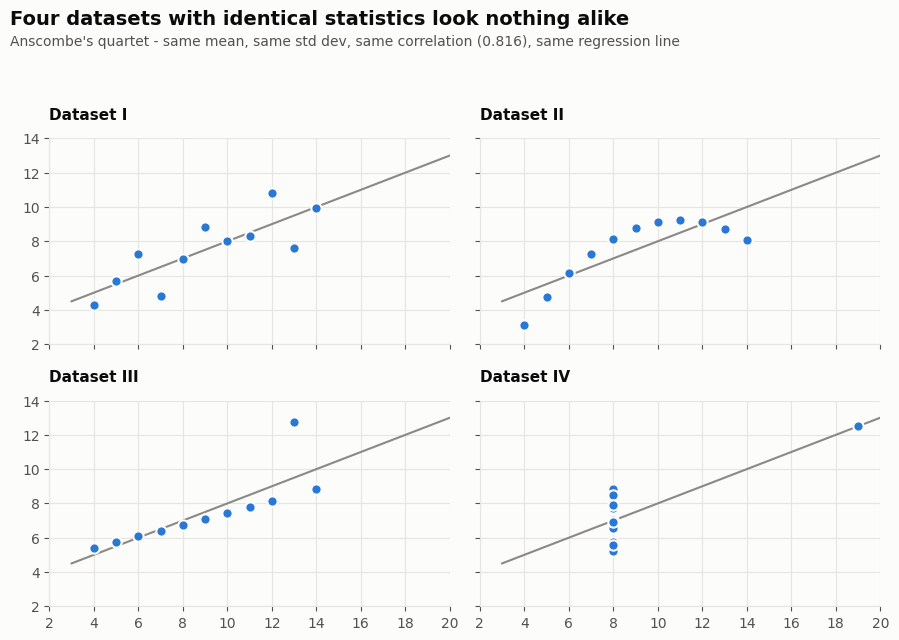

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), sharex=True, sharey=True)

for ax, (name, group) in zip(axes.flat, anscombe.groupby("dataset")):
    ax.scatter(
        group["x"],
        group["y"],
        s=55,
        color=BLUE,
        edgecolor=SURFACE,
        linewidth=1.5,
        zorder=3,
    )

    # The identical regression line, drawn on each panel.
    slope, intercept = np.polyfit(group["x"], group["y"], 1)
    xs = np.array([3, 20])
    ax.plot(xs, slope * xs + intercept, color=INK_MUTED, linewidth=1.5, zorder=2)

    ax.set_title(f"Dataset {name}", fontsize=11)
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)

fig.suptitle(
    "Four datasets with identical statistics look nothing alike",
    x=0.005,
    ha="left",
    fontsize=14,
    fontweight="bold",
    color=INK,
)
fig.text(
    0.005,
    0.925,
    "Anscombe's quartet - same mean, same std dev, same correlation (0.816), same regression line",
    ha="left",
    fontsize=10,
    color=INK_SOFT,
)
fig.tight_layout(rect=[0, 0, 1, 0.91])
save(fig, "01_why_visualize_anscombe")
plt.show()

### The punchline

Four datasets. Identical statistics. Completely different realities:

- **Dataset I** — a genuine, honest linear relationship. The statistics describe it well.
- **Dataset II** — a clean *curve*. A straight-line model is simply the wrong model, and no summary
  statistic told you that.
- **Dataset III** — a perfect straight line **plus one outlier** that drags the regression line off course.
  The statistic is being distorted by a single bad point.
- **Dataset IV** — x is constant except for one point. The "correlation of 0.816" is produced entirely by
  that one point. There is no relationship at all.

> **This is why we visualize.** Summary statistics *compress* data, and compression throws information away.
> A chart is how you check what got thrown away. You plot first, then you compute — not the other way round.

Keep this in mind for the rest of the course: **a number tells you what; a picture tells you why.**

---

# Part 2 — Meet the data

For the rest of the lecture we use the **Titanic passenger list**: 891 real passengers from the 1912
voyage, with whether they survived. It is a good teaching dataset because it has all the ingredients:
categories, numbers, groups, and missing values.

In [5]:
titanic = pd.read_csv(DATA / "titanic.csv")
print("Rows:", titanic.shape[0], " Columns:", titanic.shape[1])
titanic.head()

Rows: 891  Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# What are we actually working with?
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# How much data is missing? Always check this before you plot anything.
missing = titanic.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({"missing": missing, "percent": (missing / len(titanic) * 100).round(1)})

,missing,percent
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


Three columns have gaps:

- **Cabin** is missing for 77% of passengers — too sparse to be useful, we drop it.
- **Age** is missing for about 20% — we keep the column but we will be explicit about excluding those
  passengers when we chart age.
- **Embarked** is missing for 2 passengers — negligible.

> **Rule:** never silently drop rows. Decide what to do with missing data, and say so on the chart.
> A chart of "age" that quietly ignores 177 people is a chart that lies by omission.

---

# Part 3 — Processing the data

A chart is only the last step. Before it comes the real work: **cleaning** and **aggregating**.

Notice the shape of what we are doing. Every chart later in this notebook is built from a **small, tidy
table** — usually 3 to 6 rows. If you cannot write down the small table your chart is showing, you do not
yet know what your chart is saying.

In [8]:
df = titanic.copy()

# 1. Drop what we cannot use.
df = df.drop(columns=["Cabin", "Ticket", "PassengerId"])

# 2. Turn codes into readable labels. Charts are read by humans, so label them for humans:
#    "3rd class" is instantly clear, "3" is not.
df["Class"] = df["Pclass"].map({1: "1st class", 2: "2nd class", 3: "3rd class"})
df["Sex"] = df["Sex"].str.capitalize()
df["Outcome"] = df["Survived"].map({0: "Died", 1: "Survived"})
df["Port"] = df["Embarked"].map(
    {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
)

# 3. Derive new columns that answer questions the raw data cannot.
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 39, 59, 100],
    labels=[
        "Child (0-12)",
        "Teen (13-19)",
        "Adult (20-39)",
        "Middle (40-59)",
        "Senior (60+)",
    ],
)

df[["Class", "Sex", "Age", "AgeGroup", "FamilySize", "Outcome"]].head(8)

,Class,Sex,Age,AgeGroup,FamilySize,Outcome
0,3rd class,Male,22.0,Adult (20-39),2,Died
1,1st class,Female,38.0,Adult (20-39),2,Survived
2,3rd class,Female,26.0,Adult (20-39),1,Survived
3,1st class,Female,35.0,Adult (20-39),2,Survived
4,3rd class,Male,35.0,Adult (20-39),1,Died
5,3rd class,Male,NaN,NaN,1,Died
6,1st class,Male,54.0,Middle (40-59),1,Died
7,3rd class,Male,2.0,Child (0-12),5,Died


In [9]:
# The aggregation that most of our charts come from:
# survival RATE (not raw count) per class.
#
# Why a rate and not a count? Because there were far more 3rd class passengers
# than 1st. A raw count of survivors would tell you about ship capacity,
# not about who was more likely to live. Choose the measure that answers your question.
by_class = (
    df.groupby("Class")
    .agg(
        passengers=("Survived", "size"),
        survivors=("Survived", "sum"),
        survival_rate=("Survived", "mean"),
    )
    .reset_index()
)
by_class["survival_rate"] = (by_class["survival_rate"] * 100).round(1)
by_class

,Class,passengers,survivors,survival_rate
0,1st class,216,136,63.0
1,2nd class,184,87,47.3
2,3rd class,491,119,24.2


In [10]:
# Two more small tables we will chart later.

# Survival rate by class AND sex - a 3 x 2 grid.
by_class_sex = (
    df.groupby(["Class", "Sex"])["Survived"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="survival_rate")
)

# Survival rate across age bands - an ORDERED axis, which matters in Part 4.
by_age = (
    df.dropna(subset=["AgeGroup"])
    .groupby("AgeGroup", observed=True)
    .agg(passengers=("Survived", "size"), survival_rate=("Survived", "mean"))
    .reset_index()
)
by_age["survival_rate"] = (by_age["survival_rate"] * 100).round(1)

print("by_class_sex:")
print(by_class_sex)
print()
print("by_age:")
print(by_age)

by_class_sex:
       Class     Sex  survival_rate
0  1st class  Female           96.8
1  1st class    Male           36.9
2  2nd class  Female           92.1
3  2nd class    Male           15.7
4  3rd class  Female           50.0
5  3rd class    Male           13.5

by_age:
         AgeGroup  passengers  survival_rate
0    Child (0-12)          69           58.0
1    Teen (13-19)          95           41.1
2   Adult (20-39)         387           38.8
3  Middle (40-59)         137           39.4
4    Senior (60+)          26           26.9


---

# Part 4 — Choosing the right chart

Here is the single most useful idea in this course:

> **You do not choose a chart. You choose a question, and the question chooses the chart.**

Beginners ask *"should this be a bar or a pie?"* That is the wrong question. Ask *"what am I comparing?"*
and the chart type follows automatically.

| Your question | The data's job | Use this |
|---|---|---|
| Which category is biggest? | comparison | **Bar chart** |
| How does it change across an ordered scale? | trend | **Line chart** |
| How are the values spread out? | distribution | **Histogram** |
| Do two numbers move together? | relationship | **Scatter plot** |
| How does the whole split up? | composition | **Stacked bar** (rarely a pie) |

We will walk through each one on the Titanic data.

## 4.1 Comparison → **bar chart**

**Question:** *Did your ticket class affect your chance of survival?*

This compares a handful of separate categories. That is a bar chart, every time. Bars work because the
human eye is very good at comparing **lengths against a common baseline** — much better than it is at
comparing angles, areas or colours.

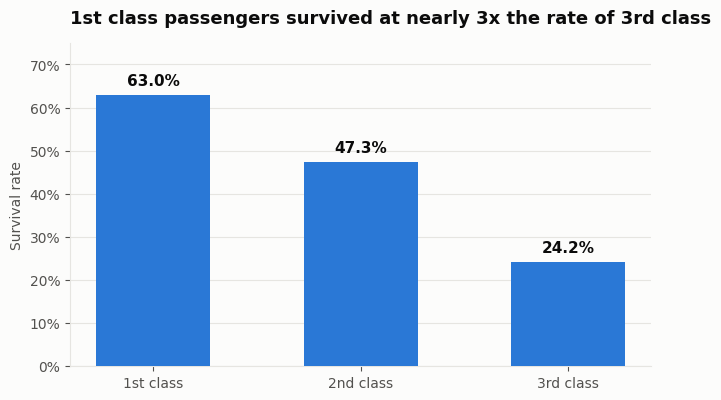

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

bars = ax.bar(
    by_class["Class"], by_class["survival_rate"], color=BLUE, width=0.55, zorder=3
)

# Label the bars directly. If a value is worth reading, put it where the eye already is -
# that beats making the reader trace a line back to the y-axis.
for bar, value in zip(bars, by_class["survival_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=INK,
    )

ax.set_title("1st class passengers survived at nearly 3x the rate of 3rd class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 75)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)  # vertical grid lines add nothing to a bar chart
ax.set_axisbelow(True)

save(fig, "02_bar_class")
plt.show()

Three things to copy from this chart:

1. **The title states the finding, not the subject.** "1st class survived at nearly 3x the rate" is a
   sentence a reader can take away. "Survival rate by class" just describes the axes, which they can
   already see. Your title is your headline — use it.
2. **The y-axis starts at zero.** For bars this is compulsory. The bar's *length* encodes the value,
   so cutting the axis makes a 62% bar look ten times a 24% bar. That is a lie told with geometry.
3. **One colour.** There is only one series here, so a second colour would be decoration pretending to be
   information. Colour should always mean something.

## 4.2 Trend across an ordered scale → **line chart**

**Question:** *Does survival change as passengers get older?*

Most textbooks say "line charts are for time". That is too narrow. The real rule is:

> Use a line when the x-axis has a **natural order** and the steps between values are meaningful.

Time is the most common ordered axis, but age bands, income brackets, education levels and dose levels are
all ordered too. The line itself is the message: it says *"these points are connected, read them in order."*

This is also why you must **never** use a line chart for unordered categories like countries or ticket
classes — the connecting line would imply a progression that does not exist.

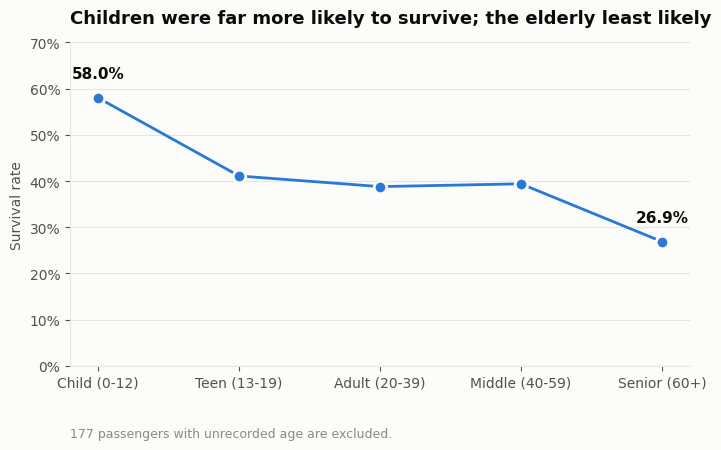

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.plot(
    by_age["AgeGroup"].astype(str),
    by_age["survival_rate"],
    color=BLUE,
    marker="o",
    markersize=9,
    markerfacecolor=BLUE,
    markeredgecolor=SURFACE,
    markeredgewidth=2,
    zorder=3,
)

# Label only the two points that carry the message, not every point.
for i, row in by_age.iterrows():
    if row["AgeGroup"] in ("Child (0-12)", "Senior (60+)"):
        ax.annotate(
            f"{row['survival_rate']}%",
            (str(row["AgeGroup"]), row["survival_rate"]),
            textcoords="offset points",
            xytext=(0, 14),
            ha="center",
            fontsize=11,
            fontweight="bold",
            color=INK,
        )

ax.set_title("Children were far more likely to survive; the elderly least likely")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
ax.text(
    0,
    -0.22,
    "177 passengers with unrecorded age are excluded.",
    transform=ax.transAxes,
    fontsize=9,
    color=INK_MUTED,
)

save(fig, "03_line_age")
plt.show()

Note the footnote: **177 passengers with unrecorded age are excluded.** We promised earlier not to hide
missing data, and this is how you keep that promise. It costs one line and it is the difference between an
honest chart and a misleading one.

Note also that we labelled **two** points, not all five. Labelling every point turns a chart back into a
table. Label the points that make your argument.

## 4.3 Distribution → **histogram**

**Question:** *What did the age profile of the ship actually look like?*

A bar chart and a histogram look similar and are completely different animals:

- A **bar chart** compares *separate categories*. The bars have gaps because the categories are unrelated.
- A **histogram** shows how *one continuous variable* is spread out. The bars touch because the underlying
  scale is continuous — there is no gap between "age 29" and "age 30".

Use a histogram whenever you want to know the *shape* of your data: where the bulk sits, whether it is
skewed, whether there are surprises in the tails.

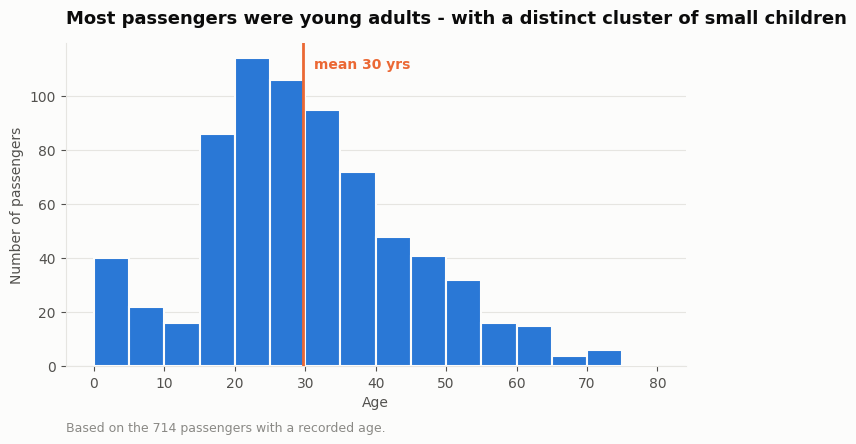

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ages = df["Age"].dropna()
ax.hist(
    ages,
    bins=np.arange(0, 85, 5),
    color=BLUE,
    edgecolor=SURFACE,
    linewidth=1.5,
    zorder=3,
)

mean_age = ages.mean()
ax.axvline(mean_age, color=ORANGE, linewidth=2, zorder=4)
ax.text(
    mean_age + 1.5,
    ax.get_ylim()[1] * 0.92,
    f"mean {mean_age:.0f} yrs",
    color=ORANGE,
    fontsize=10,
    fontweight="bold",
)

ax.set_title(
    "Most passengers were young adults - with a distinct cluster of small children"
)
ax.set_xlabel("Age")
ax.set_ylabel("Number of passengers")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.text(
    0,
    -0.20,
    f"Based on the {len(ages)} passengers with a recorded age.",
    transform=ax.transAxes,
    fontsize=9,
    color=INK_MUTED,
)

save(fig, "04_histogram_age")
plt.show()

This chart shows you something no summary statistic would have: the mean age is 30, but the distribution is
**right-skewed** with a visible **bump of young children** around ages 0–5 (families travelling together).
"Mean age 30" hides both facts entirely — which is Part 1's lesson showing up again in real data.

**On bin width:** the number of bins is a real decision, not a default. Too few bins and you flatten the
detail away; too many and you are looking at noise. Try changing `bins` above to `10` and then to `60` and
see how differently the same data reads.

## 4.4 Relationship → **scatter plot**

**Question:** *Did passengers who paid more tend to be younger or older?*

When you have **two numeric variables** and want to know whether they move together, the scatter plot is the
only real answer. Each dot is one observation, positioned by both variables at once.

This is exactly the chart that saved us in Part 1 — scatter plots are how you *see* a relationship rather
than trusting a correlation coefficient to describe it.

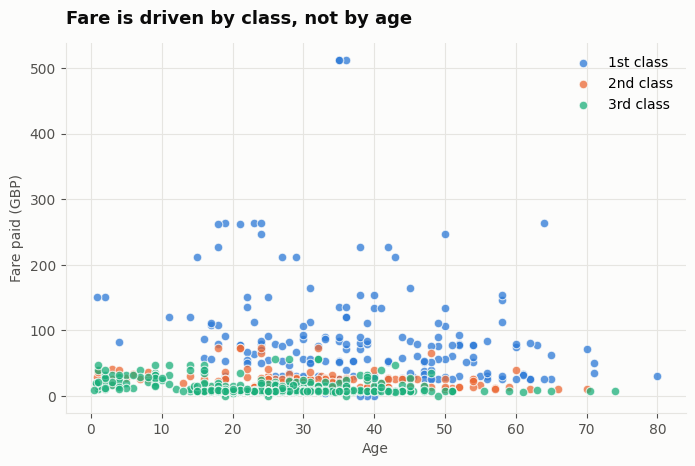

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.8))

sub = df.dropna(subset=["Age", "Fare"])
for colour, (cls, group) in zip([BLUE, ORANGE, AQUA], sub.groupby("Class")):
    ax.scatter(
        group["Age"],
        group["Fare"],
        s=38,
        color=colour,
        alpha=0.75,
        edgecolor=SURFACE,
        linewidth=0.8,
        label=cls,
        zorder=3,
    )

ax.set_title("Fare is driven by class, not by age")
ax.set_xlabel("Age")
ax.set_ylabel("Fare paid (GBP)")
ax.legend(loc="upper right", title=None)
ax.set_axisbelow(True)

save(fig, "05_scatter_age_fare")
plt.show()

The scatter shows there is essentially **no** age-to-fare relationship — the cloud does not tilt. What it
shows instead is that the three class colours form three horizontal *bands*. Fare is explained by class, not
by age.

That is a genuinely useful outcome: **a scatter plot that shows no relationship is still an answer.**

Two craft points:

- We used **three colours for three groups** and gave them a legend. Colour here is carrying real
  information (class), which is the only reason to introduce it.
- The dots are **semi-transparent** (`alpha=0.75`). With hundreds of overlapping points, opaque dots hide
  each other and you cannot see where the data is dense.

## 4.5 Composition → **stacked bar**, and the case against the pie chart

**Question:** *How did each class split between survivors and deaths?*

Pie charts are the most over-used chart in the world, so let's settle it with a direct comparison. Below,
the same data is drawn twice — as pies, and as a stacked bar.

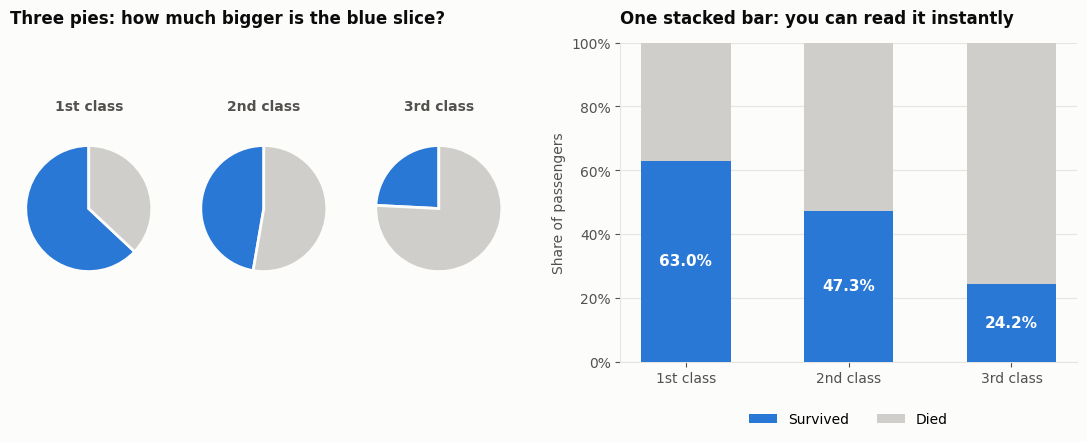

In [15]:
fig, axes = plt.subplots(
    1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1.15, 1]}
)

# ---- LEFT: three pie charts (the common approach) ----
left = axes[0]
left.axis("off")
for i, cls in enumerate(["1st class", "2nd class", "3rd class"]):
    row = by_class[by_class["Class"] == cls].iloc[0]
    rate = row["survival_rate"]
    inset = left.inset_axes([i / 3, 0.12, 0.30, 0.72])
    inset.pie(
        [rate, 100 - rate],
        colors=[BLUE, QUIET],
        startangle=90,
        wedgeprops={"edgecolor": SURFACE, "linewidth": 2},
    )
    inset.set_title(cls, fontsize=10, color=INK_SOFT, loc="center")
left.set_title("Three pies: how much bigger is the blue slice?", fontsize=12, color=INK)

# ---- RIGHT: one stacked bar (the better approach) ----
right = axes[1]
survived = by_class["survival_rate"].values
died = 100 - survived
right.bar(
    by_class["Class"], survived, color=BLUE, width=0.55, label="Survived", zorder=3
)
right.bar(
    by_class["Class"],
    died,
    bottom=survived,
    color=QUIET,
    width=0.55,
    label="Died",
    zorder=3,
)

for x, value in enumerate(survived):
    right.text(
        x,
        value / 2,
        f"{value}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=11,
    )

right.set_ylim(0, 100)
right.set_ylabel("Share of passengers")
right.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
right.xaxis.grid(False)
right.set_axisbelow(True)
right.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
right.set_title("One stacked bar: you can read it instantly", fontsize=12, color=INK)

fig.tight_layout()
save(fig, "06_pie_vs_stacked_bar")
plt.show()

### Why the bar wins

Look at the pies and try to answer "how much bigger is 1st class's blue slice than 2nd class's?" You
cannot, quickly. Now look at the bar. You can.

The reason is a well-studied fact about human perception: **we judge length accurately and angle badly.**
A pie asks you to compare angles across three separate circles, which is close to the hardest possible
version of the task.

**When a pie chart is acceptable:**
- Two or three slices, at most.
- You only need "roughly half" / "a small minority", not a precise comparison.
- The slices genuinely sum to a meaningful whole.

**When it is not:**
- More than about four slices.
- Comparing across multiple pies (as above).
- Slices of similar size — you will not be able to tell them apart.

> Honest rule of thumb: if you are reaching for a pie chart, try a bar chart first. You will usually keep it.

## 4.6 Two categories at once → **grouped bar**

**Question:** *Did class matter more than sex, or the other way round?*

Sometimes you genuinely need two categorical dimensions in one chart. A grouped bar handles this — but note
this is the **limit**, not a starting point. Two dimensions works. Three is where charts start to fall apart,
which is exactly what Part 5 is about.

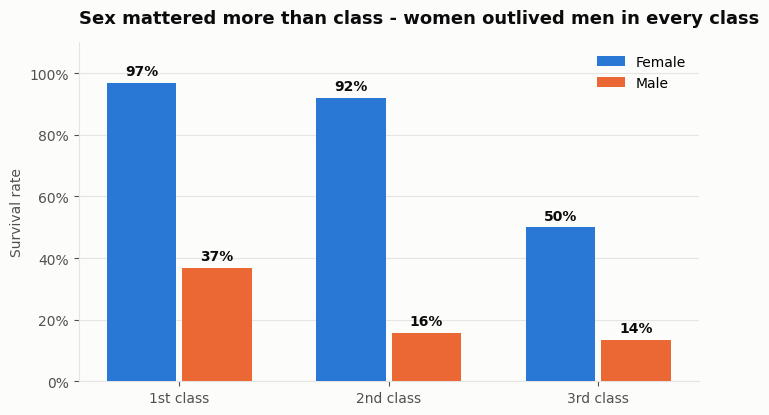

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.4))

classes = ["1st class", "2nd class", "3rd class"]
width = 0.36
x = np.arange(len(classes))

for i, (sex, colour) in enumerate(zip(["Female", "Male"], [BLUE, ORANGE])):
    values = [
        by_class_sex.query("Class == @c and Sex == @sex")["survival_rate"].iloc[0]
        for c in classes
    ]
    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width=width * 0.92,
        color=colour,
        label=sex,
        zorder=3,
    )
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1.5,
            f"{value:.0f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=INK,
        )

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_title("Sex mattered more than class - women outlived men in every class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.legend(loc="upper right")

save(fig, "07_grouped_bar_class_sex")
plt.show()

This chart earns its second dimension, because the comparison **is** the message: the gap between the blue
and orange bars is larger than the gap across classes. "Women and children first" shows up more strongly
than wealth did.

Notice the bars are **grouped by class** rather than by sex. That choice is not neutral — you group by the
dimension you want your reader to compare *within*. Here we want female-vs-male compared side by side, so
those two bars are placed next to each other. Swap the grouping and the chart answers a different question.

---

# Part 5 — One chart, one message

You now know how to pick a chart type. The last lesson of Week 1 is about **restraint**.

Every chart should be able to finish this sentence: *"This chart shows that ________."*

If your answer needs an "and" — *"it shows class matters, and sex matters, and age matters, and which port
you boarded at"* — you do not have one chart. You have four charts fighting for the same rectangle.

Let's build the bad version deliberately, so you can see exactly how it fails.

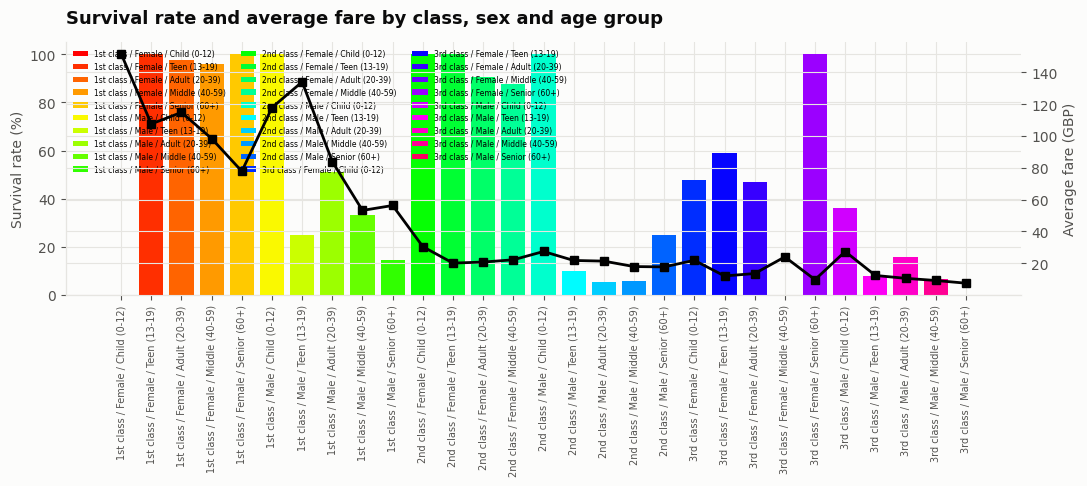

In [17]:
# =====================================================================
#  DELIBERATELY BAD CHART - this is an anti-example. Do not copy it.
#  It tries to show class AND sex AND age group AND average fare, at once.
# =====================================================================

messy = (
    df.dropna(subset=["AgeGroup"])
    .groupby(["Class", "Sex", "AgeGroup"], observed=True)
    .agg(rate=("Survived", "mean"), fare=("Fare", "mean"))
    .reset_index()
)
messy["rate"] *= 100
messy["label"] = (
    messy["Class"] + " / " + messy["Sex"] + " / " + messy["AgeGroup"].astype(str)
)

fig, ax = plt.subplots(figsize=(11, 5))

rainbow = plt.cm.hsv(np.linspace(0, 0.95, len(messy)))
for i, (colour, row) in enumerate(zip(rainbow, messy.itertuples())):
    ax.bar(i, row.rate, color=colour, zorder=3, label=row.label)

# A SECOND Y-AXIS - the single most common way to make a chart lie.
ax2 = ax.twinx()
ax2.plot(range(len(messy)), messy["fare"], color="black", marker="s", linewidth=2)
ax2.set_ylabel("Average fare (GBP)")

ax.set_xticks(range(len(messy)))
ax.set_xticklabels(messy["label"], rotation=90, fontsize=7)
ax.set_ylabel("Survival rate (%)")
ax.set_title("Survival rate and average fare by class, sex and age group")
ax.legend(loc="upper left", ncol=3, fontsize=5.5)

fig.tight_layout()
save(fig, "08_messy_bad_example")
plt.show()

### What went wrong — count the failures

This chart is technically correct. Every number in it is accurate. It is still useless.

1. **No message.** What is it telling you? It has no answer, because it was never asked a question.
2. **Too many categories.** 29 bars with 29 rotated labels in 7pt type. Nobody will read those.
3. **A second y-axis.** The black line uses a different scale from the bars. Where the line "crosses" the
   bars is meaningless — and you can make the line appear to lead or lag the bars just by rescaling the axis.
   **Never use two y-axes.** If you have two measures, draw two charts.
4. **A rainbow palette.** 29 generated hues carrying no information. The colour is decoration, and many
   of these hues are indistinguishable from their neighbours - especially to a colour-blind reader.
5. **A legend nobody can use.** 29 entries, overlapping each other, covering the data - and cross-referencing
   x-axis labels that already say the same thing.
6. **A title that describes the axes.** "Survival rate and average fare by class, sex and age group" tells
   you what was plotted, not what you should conclude.
7. **It hides its own sample sizes - and that one is serious.** Look at the very first bar,
   *1st class / Female / Child*: it sits at 0%, which reads as "first-class girls all died". In fact that
   group contains **exactly one passenger**. The bar beside it covers 43 people. The chart draws both at
   identical visual weight, so a single person and a whole cohort make the same claim on your eye. This is
   what over-splitting your data does: slice it finely enough and you end up charting noise as if it were
   a finding.

Now the fix. We do **not** fix this chart by tidying it. We fix it by deciding what it is for.

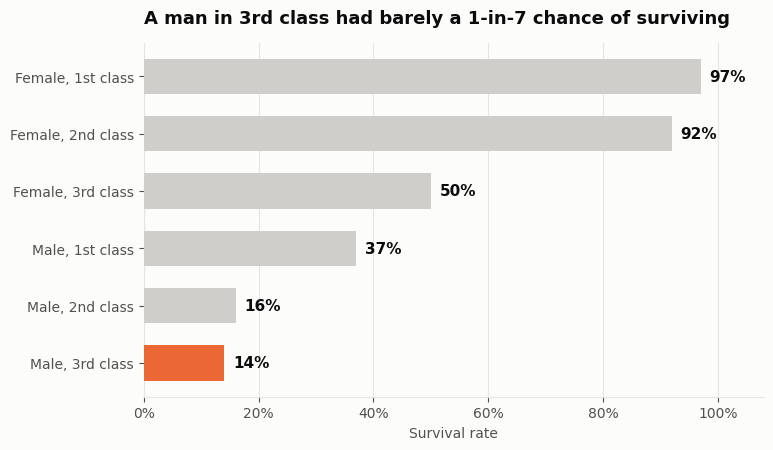

In [18]:
# =====================================================================
#  THE FIX - same underlying data, one question, one message.
#  Question: "Which group had the worst odds on the Titanic?"
# =====================================================================

focus = (
    df.groupby(["Class", "Sex"])["Survived"]
    .mean()
    .mul(100)
    .round(0)
    .reset_index(name="rate")
    .sort_values("rate")
)
focus["label"] = focus["Sex"] + ", " + focus["Class"]

fig, ax = plt.subplots(figsize=(8, 4.6))

# Grey for context, ONE colour for the message. Colour is the argument.
colours = [ORANGE if i == 0 else QUIET for i in range(len(focus))]
bars = ax.barh(focus["label"], focus["rate"], color=colours, height=0.62, zorder=3)

for bar, value in zip(bars, focus["rate"]):
    ax.text(
        value + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=INK,
    )

ax.set_title("A man in 3rd class had barely a 1-in-7 chance of surviving")
ax.set_xlabel("Survival rate")
ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(lambda v, p: f"{v:.0f}%")
ax.yaxis.grid(False)
ax.set_axisbelow(True)

save(fig, "09_clear_one_message")
plt.show()

### What changed

| The messy chart | The clear chart |
|---|---|
| 4 variables | 2 variables |
| Groups as small as 1 person | Smallest group is 76 people |
| 29 bars | 6 bars |
| 29 rainbow colours | 1 colour + grey |
| 2 y-axes | 1 axis |
| Title describes the axes | Title states the finding |
| Reader has to work it out | Reader gets it in 2 seconds |

The technique in the second chart is worth naming, because you will use it constantly:

> **Grey is a colour.** Push the context into grey and spend your one bright colour on the thing you want
> the reader to look at. A chart where everything is highlighted has nothing highlighted.

We also **sorted the bars by value**. Class and sex have no natural order, so sorting by the number costs
nothing and makes the ranking readable instantly. Sort unordered categories, always.

Finally — we did not lose the other information. It simply belongs in **other charts**. The messy chart
tried to be a report. A report is made of several simple charts, not one complicated one.

---

# Part 6 — Week 1 takeaways

### 1. Why we visualize
Summary statistics compress data, and compression hides things. Anscombe's quartet has four datasets with
identical means, standard deviations and correlations, and four completely different shapes. **Plot first,
then compute.**

### 2. The question chooses the chart

| Your question | Chart | Why |
|---|---|---|
| Which category is biggest? | **Bar** | Eyes compare lengths accurately |
| How does it change across an ordered scale? | **Line** | The line says "read these in order" |
| How is one variable spread out? | **Histogram** | Shows shape, skew and outliers |
| Do two numbers move together? | **Scatter** | Shows the relationship, not a summary of it |
| How does a whole split up? | **Stacked bar** | Beats a pie in almost every case |
| Two categories at once? | **Grouped bar** | But this is the ceiling, not the floor |

### 3. One chart, one message
Finish the sentence *"this chart shows that ______"*. If you need an "and", split it into two charts.

### 4. The craft rules worth memorising

- **Title the finding, not the subject.** "1st class survived 3x more often" beats "Survival by class".
- **Bars start at zero.** Always. The length is the value.
- **Never use two y-axes.** Two measures means two charts.
- **Colour must mean something.** If it is decoration, remove it.
- **Grey is a colour.** Mute the context, highlight the message.
- **Sort unordered categories by value.** Ordered ones keep their order.
- **Label selectively.** If you label every point you have made a table.
- **Declare your missing data** on the chart, not in a footnote nobody reads.
- **Use a colour-blind-safe palette.** Roughly 1 in 12 men cannot read a red/green chart.

---

### Exercises for next week

Using the same `df`, and applying everything above:

1. **Family size and survival.** Did travelling alone help or hurt? Pick the chart type deliberately and
   justify your choice in a markdown cell.
2. **Port of embarkation.** Is there a survival difference by `Port`? Then check whether it is real or
   whether `Port` is just standing in for `Class`. (This is a preview of a big idea: charts can show
   correlation that is really something else in disguise.)
3. **Fix a bad chart.** Find a chart in a newspaper or on social media that breaks at least two rules from
   the list above. Write down which rules, and sketch the version you would draw instead.
4. **Redraw one of our charts badly** — on purpose. Cut the y-axis, add a rainbow, add a second axis. Then
   write a paragraph about what a reader would wrongly conclude from your version.

All the charts from this notebook were saved into the `charts/` folder as PNGs, ready for slides.